## 1. Cài đặt thư viện

In [4]:
!pip install stable-baselines3[extra] gymnasium matplotlib numpy -q
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 5.4 MB/s eta 0:00:00
GPU: Tesla P100-PCIE-16GB


## 2. Khởi tạo 3 bản đồ tuần tra

In [7]:
import json, os

os.makedirs("/kaggle/working/maps", exist_ok=True)

maps = {
    "map_simple.json": {
        "name": "simple_grid",
        "grid_size": 10,
        "obstacles": [[3,3],[3,4],[6,6],[6,7]],
        "start_position": [0,0],
        "max_steps": 600
    },
    "map_mixed.json": {
        "name": "mixed_obstacles",
        "grid_size": 10,
        "obstacles": [[2,5],[3,5],[4,5],[5,2],[6,2],[7,2],[7,3]],
        "start_position": [0,0],
        "max_steps": 600
    },
    "map_bottleneck.json": {
        "name": "bottleneck",
        "grid_size": 10,
        "obstacles": [
            [5,0],[5,1],[5,2],[5,3],
            [5,5],[5,6],[5,7],[5,8],[5,9]
        ],
        "start_position": [0,0],
        "max_steps": 800
    }
}

for filename, data in maps.items():
    with open(f"/kaggle/working/maps/{filename}", "w") as f:
        json.dump(data, f, indent=2)
print("Maps created:", os.listdir("/kaggle/working/maps"))

Maps created: ['map_mixed.json', 'map_bottleneck.json', 'map_simple.json']


## 3. Môi trường UAVPatrolEnv

In [8]:
import gymnasium as gym
import numpy as np
import json
from collections import deque
from gymnasium import spaces


class UAVPatrolEnv(gym.Env):
    metadata = {"render_modes": ["human"]}

    # ── Reward hyper-params ──────────────────────────────────────
    EXPLORE_REWARD   = 60.0
    OBSTACLE_PENALTY = 20.0
    COVERAGE_SCALE   = 25.0
    FRONTIER_SCALE   = 12.0
    REVISIT_MULT     = 1.5
    REVISIT_CAP      = 25.0
    BFS_SCALE        = 8.0
    STEP_PENALTY     = 0.1
    COMPLETE_BONUS   = 3000.0
    PARTIAL_SCALE    = 600.0
    PASSAGE_BONUS    = 80.0

    def __init__(self, grid_size=10, max_steps=600, map_file=None):
        super().__init__()
        if map_file:
            with open(map_file) as f:
                config = json.load(f)
            grid_size = config.get("grid_size", grid_size)
            max_steps = config.get("max_steps", max_steps)
            self.start_position = config.get("start_position", [0, 0])
            self.obstacles      = config.get("obstacles", [])
        else:
            self.start_position = [0, 0]
            self.obstacles      = []

        self.grid_size  = grid_size
        self.max_steps  = max_steps
        self.obstacles  = set(tuple(o) for o in self.obstacles)
        self.free_cells = grid_size * grid_size - len(self.obstacles)
        self.passages   = self._detect_passages()

        self.action_space = spaces.Discrete(4)
        obs_size = grid_size * grid_size * 3 + 3   # 303 chiều
        self.observation_space = spaces.Box(low=0, high=1,
                                            shape=(obs_size,), dtype=np.float32)
        self.reset()

    def _detect_passages(self):
        passages, g = set(), self.grid_size
        for r in range(g):
            if sum(1 for c in range(g) if (r,c) in self.obstacles) >= max(1, int(g*0.7)):
                for c in range(g):
                    if (r,c) not in self.obstacles: passages.add((r,c))
        for c in range(g):
            if sum(1 for r in range(g) if (r,c) in self.obstacles) >= max(1, int(g*0.7)):
                for r in range(g):
                    if (r,c) not in self.obstacles: passages.add((r,c))
        return passages

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.coverage    = np.zeros((self.grid_size, self.grid_size), dtype=np.float32)
        self.visit_count = np.zeros((self.grid_size, self.grid_size), dtype=np.float32)
        self._visited_passages = set()
        while True:
            x = np.random.randint(0, self.grid_size)
            y = np.random.randint(0, self.grid_size)
            if (x, y) not in self.obstacles: break
        self.uav_pos = [x, y]
        self.coverage[x, y] = self.visit_count[x, y] = 1.0
        self.steps = 0
        return self._get_obs(), {}

    def _get_obs(self):
        obs_map = np.zeros((self.grid_size, self.grid_size), dtype=np.float32)
        for o in self.obstacles: obs_map[o] = 1.0
        mv = self.visit_count.max()
        visit_norm = (self.visit_count / mv if mv > 0 else self.visit_count).flatten()
        dist = self._bfs_nearest_frontier()
        dist_norm = np.array([min(dist, self.grid_size*2) / (self.grid_size*2)], dtype=np.float32)
        pos = np.array(self.uav_pos, dtype=np.float32) / self.grid_size
        return np.concatenate([self.coverage.flatten(), obs_map.flatten(),
                               visit_norm, pos, dist_norm]).astype(np.float32)

    def _bfs_nearest_frontier(self):
        sx, sy = self.uav_pos
        if self.coverage[sx, sy] == 0: return 0
        visited = {(sx, sy)}
        queue   = deque([(sx, sy, 0)])
        while queue:
            cx, cy, d = queue.popleft()
            for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
                nx, ny = cx+dx, cy+dy
                if (0 <= nx < self.grid_size and 0 <= ny < self.grid_size
                        and (nx,ny) not in visited and (nx,ny) not in self.obstacles):
                    if self.coverage[nx, ny] == 0: return d + 1
                    visited.add((nx,ny)); queue.append((nx, ny, d+1))
        return self.grid_size * 2

    def step(self, action):
        x, y = self.uav_pos; old_pos = [x, y]
        if   action == 0: x -= 1
        elif action == 1: x += 1
        elif action == 2: y -= 1
        elif action == 3: y += 1
        x = int(np.clip(x, 0, self.grid_size-1))
        y = int(np.clip(y, 0, self.grid_size-1))
        reward = 0.0
        if (x, y) in self.obstacles:
            reward -= self.OBSTACLE_PENALTY; x, y = old_pos
        self.uav_pos = [x, y]; self.visit_count[x, y] += 1
        if self.coverage[x, y] == 0:
            self.coverage[x, y] = 1.0; reward += self.EXPLORE_REWARD
        else:
            reward -= min(self.visit_count[x,y]**2 * self.REVISIT_MULT, self.REVISIT_CAP)
        if (x,y) in self.passages and (x,y) not in self._visited_passages:
            reward += self.PASSAGE_BONUS; self._visited_passages.add((x,y))
        frontier = sum(1 for dx,dy in [(-1,0),(1,0),(0,-1),(0,1)]
                      if 0<=x+dx<self.grid_size and 0<=y+dy<self.grid_size
                      and self.coverage[x+dx,y+dy]==0 and (x+dx,y+dy) not in self.obstacles)
        reward += frontier * self.FRONTIER_SCALE
        d = self._bfs_nearest_frontier()
        reward += (self.BFS_SCALE / (d+1)) if d > 0 else 3.0
        coverage_ratio = float(self.coverage.sum()) / self.free_cells
        reward += coverage_ratio * self.COVERAGE_SCALE - self.STEP_PENALTY
        self.steps += 1
        terminated = truncated = False
        if coverage_ratio >= 0.97:
            reward += self.COMPLETE_BONUS; terminated = True
        elif self.steps >= self.max_steps:
            reward += coverage_ratio * self.PARTIAL_SCALE; truncated = True
        return self._get_obs(), reward, terminated, truncated, {}

    def render(self):
        grid = np.full((self.grid_size, self.grid_size), ".")
        for o in self.obstacles: grid[o] = "#"
        grid[self.uav_pos[0], self.uav_pos[1]] = "U"
        for row in grid: print(" ".join(row))
        print(f"Coverage: {self.coverage.sum()/self.free_cells:.1%}  Steps: {self.steps}")


# ── Sanity check ─────────────────────────────────────────────────
env_test = UAVPatrolEnv(map_file="/kaggle/working/maps/map_bottleneck.json")
obs, _ = env_test.reset()
print("Obs shape :", obs.shape)      # (303,)
print("Passages  :", env_test.passages)
print("Free cells:", env_test.free_cells)

Obs shape : (303,)
Passages  : {(5, 4)}
Free cells: 91


## 4. So sánh biến thể Reward Function

Thử nghiệm 3 biến thể reward trên Simple Map để chọn biến thể tốt nhất:
- **Variant A** — Simple: chỉ có explore reward + obstacle penalty (baseline đơn giản)
- **Variant B** — Dense: thêm frontier + coverage bonus (không có BFS/passage)
- **Variant C** — Full (hiện tại): tất cả thành phần + BFS + passage bonus

So sánh 3 biến thể reward — 2,000,000 steps

[Variant A (Simple)]
  simple=41.5%  mixed=24.3%  bottleneck=10.1%  → mean=25.3%

[Variant B (Dense)]
  simple=59.8%  mixed=14.1%  bottleneck=10.7%  → mean=28.2%

[Variant C (Full )]
  simple=97.9%  mixed=17.7%  bottleneck=6.3%  → mean=40.6%

Variant                Simple   Mixed  Bottleneck    Mean
───────────────────────────────────────────────────────
Variant A (Simple)      41.5%    24.3%        10.1%    25.3%
Variant B (Dense)       59.8%    14.1%        10.7%    28.2%
Variant C (Full )       97.9%    17.7%         6.3%    40.6% ★ BEST


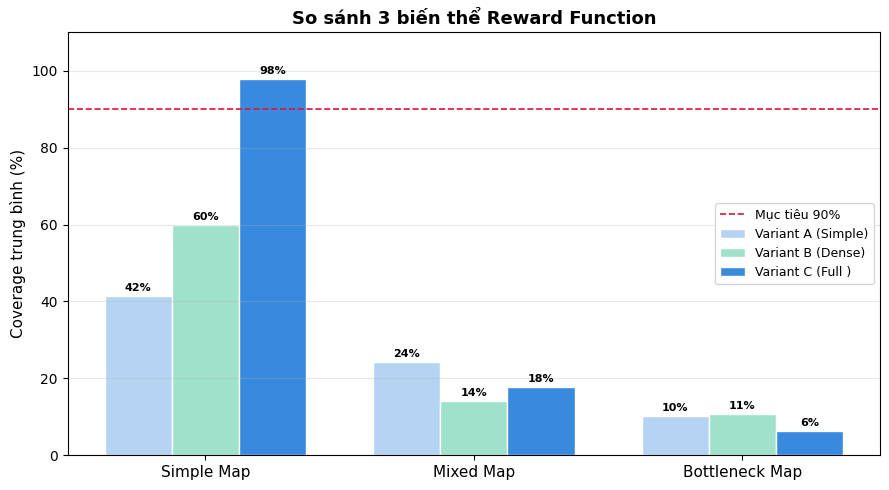

reward_variants_comparison.png đã lưu


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.monitor import Monitor


# ── Định nghĩa 3 biến thể reward ────────────────────────────────
REWARD_VARIANTS = {
    "Variant A\n(Simple)": dict(
        EXPLORE_REWARD=50.0, OBSTACLE_PENALTY=20.0,
        COVERAGE_SCALE=150.0, FRONTIER_SCALE=0.0,
        REVISIT_MULT=0.0, REVISIT_CAP=0.0,
        BFS_SCALE=0.0, STEP_PENALTY=0.05,
        COMPLETE_BONUS=3000.0, PARTIAL_SCALE=0.0,
        PASSAGE_BONUS=0.0,
    ),
    "Variant B\n(Dense)": dict(
        EXPLORE_REWARD=50.0, OBSTACLE_PENALTY=20.0,
        COVERAGE_SCALE=30.0, FRONTIER_SCALE=15.0,
        REVISIT_MULT=1.0, REVISIT_CAP=15.0,
        BFS_SCALE=0.0, STEP_PENALTY=0.1,
        COMPLETE_BONUS=3000.0, PARTIAL_SCALE=300.0,
        PASSAGE_BONUS=0.0,
    ),
    "Variant C\n(Full )": dict(
        EXPLORE_REWARD=60.0, OBSTACLE_PENALTY=20.0,
        COVERAGE_SCALE=25.0, FRONTIER_SCALE=12.0,
        REVISIT_MULT=1.5, REVISIT_CAP=25.0,
        BFS_SCALE=8.0, STEP_PENALTY=0.1,
        COMPLETE_BONUS=3000.0, PARTIAL_SCALE=600.0,
        PASSAGE_BONUS=80.0,
    ),
}

TRAIN_STEPS = 2_000_000
EVAL_EPS    = 10
SEED        = 42
MAP_FILE    = "/kaggle/working/maps/map_simple.json"

def make_variant_env(params, map_file):
    def _init():
        env = UAVPatrolEnv(map_file=map_file)
        for k, v in params.items():
            setattr(env, k, v)
        return Monitor(env)
    return _init

results = {}
print("=" * 55)
print(f"So sánh 3 biến thể reward — {TRAIN_STEPS:,} steps")
print("=" * 55)

for vname, params in REWARD_VARIANTS.items():
    label = vname.replace("\n", " ")
    print(f"\n[{label}]", flush=True)
    vec = DummyVecEnv([make_variant_env(params, MAP_FILE)] * 4)
    vec = VecNormalize(vec, norm_obs=False, norm_reward=True,
                       clip_reward=10, gamma=0.995)
    model = PPO("MlpPolicy", vec, verbose=0, seed=SEED,
                learning_rate=2e-4, gamma=0.995, n_steps=2048,
                batch_size=256, ent_coef=0.04, n_epochs=10,
                policy_kwargs=dict(net_arch=[256, 256]), device="cpu")
    model.learn(total_timesteps=TRAIN_STEPS, progress_bar=False)

    # Eval trên 3 map
    map_results = {}
    for mp, mname in [("/kaggle/working/maps/map_simple.json",     "simple"),
                      ("/kaggle/working/maps/map_mixed.json",      "mixed"),
                      ("/kaggle/working/maps/map_bottleneck.json", "bottleneck")]:
        covs = []
        for _ in range(EVAL_EPS):
            env = UAVPatrolEnv(map_file=mp)
            for k, v in params.items(): setattr(env, k, v)
            obs, _ = env.reset()
            done = False
            while not done:
                act, _ = model.predict(obs, deterministic=True)
                obs, _, t, tr, _ = env.step(int(act))
                done = t or tr
            covs.append(env.coverage.sum() / env.free_cells * 100)
        map_results[mname] = round(float(np.mean(covs)), 1)
    map_results["mean"] = round(float(np.mean(list(map_results.values()))), 1)
    results[label] = map_results
    vec.close()
    print(f"  simple={map_results['simple']:.1f}%  "
          f"mixed={map_results['mixed']:.1f}%  "
          f"bottleneck={map_results['bottleneck']:.1f}%  "
          f"→ mean={map_results['mean']:.1f}%")

# ── Bảng so sánh ─────────────────────────────────────────────────
print("\n" + "=" * 55)
print(f"{'Variant':<20} {'Simple':>8} {'Mixed':>7} {'Bottleneck':>11} {'Mean':>7}")
print("─" * 55)
for name, r in results.items():
    best = name == max(results, key=lambda k: results[k]["mean"])
    flag = " ★ BEST" if best else ""
    print(f"{name:<20} {r['simple']:>7.1f}%  {r['mixed']:>6.1f}%  "
          f"{r['bottleneck']:>10.1f}%  {r['mean']:>6.1f}%{flag}")

# ── Biểu đồ ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
x      = np.arange(3)
maps   = ["simple", "mixed", "bottleneck"]
colors = ["#B5D4F4", "#9FE1CB", "#378ADD"]
names  = list(results.keys())
w      = 0.25

for i, (name, color) in enumerate(zip(names, colors)):
    vals = [results[name][m] for m in maps]
    bars = ax.bar(x + (i-1)*w, vals, w, label=name.replace("\n"," "),
                  color=color, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
                f"{v:.0f}%", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(["Simple Map", "Mixed Map", "Bottleneck Map"], fontsize=11)
ax.set_ylabel("Coverage trung bình (%)", fontsize=11)
ax.set_title("So sánh 3 biến thể Reward Function", fontsize=13, fontweight="bold")
ax.axhline(90, color="crimson", ls="--", lw=1.2, label="Mục tiêu 90%")
ax.set_ylim(0, 110)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("reward_variants_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("reward_variants_comparison.png đã lưu")

## 5. Huấn luyện PPO Agent (Variant C — Full reward)

In [15]:
import random, os
import numpy as np
import torch
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback, CallbackList, BaseCallback
from stable_baselines3.common.utils import set_random_seed

# ── Fix reproducibility ──────────────────────────────────────────
MASTER_SEED = 42
random.seed(MASTER_SEED)
np.random.seed(MASTER_SEED)
torch.manual_seed(MASTER_SEED)
torch.cuda.manual_seed_all(MASTER_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
set_random_seed(MASTER_SEED)

# ── Tạo thư mục lưu checkpoint (Kaggle: download từ Output tab) ──
BACKUP_DIR = "/kaggle/working/checkpoints"
os.makedirs(BACKUP_DIR, exist_ok=True)

# ── Callbacks ────────────────────────────────────────────────────
class CoverageLogCallback(BaseCallback):
    def __init__(self, check_freq=200_000):
        super().__init__()
        self.check_freq = check_freq
        self.map_paths  = ["/kaggle/working/maps/map_simple.json",
                           "/kaggle/working/maps/map_mixed.json",
                           "/kaggle/working/maps/map_bottleneck.json"]
    def _on_step(self):
        if self.n_calls % self.check_freq == 0:
            results = []
            for mp in self.map_paths:
                covs = []
                for _ in range(5):
                    e = UAVPatrolEnv(map_file=mp)
                    obs, _ = e.reset(seed=MASTER_SEED)
                    done = False
                    while not done:
                        act, _ = self.model.predict(obs, deterministic=True)
                        obs, _, t, tr, _ = e.step(int(act))
                        done = t or tr
                    covs.append(e.coverage.sum() / e.free_cells)
                results.append(np.mean(covs))
            name = lambda p: p.split("_")[-1].replace(".json","")
            line = "  |  ".join(f"{name(p):12s}: {r:.1%}"
                                for p, r in zip(self.map_paths, results))
            goal = " ✓ GOAL" if min(results) >= 0.90 else ""
            print(f"[{self.num_timesteps:>9,d} steps]  {line}{goal}")
        return True

class AutoSaveCallback(BaseCallback):
    def __init__(self, train_env, save_freq=1_000_000,
                 save_dir=BACKUP_DIR):
        super().__init__()
        self.save_freq = save_freq
        self.save_dir  = save_dir
        self.train_env = train_env
    def _on_step(self):
        if self.n_calls % self.save_freq == 0:
            tag = f"{self.num_timesteps//1_000_000}M"
            self.model.save(f"{self.save_dir}/ppo_uav_{tag}")
            self.train_env.save(f"{self.save_dir}/vec_normalize_{tag}.pkl")
            print(f"   [{tag} steps] Checkpoint saved → /kaggle/working/checkpoints")
        return True

# ── Envs ─────────────────────────────────────────────────────────
def make_env(map_path, rank=0):
    def _init():
        env = UAVPatrolEnv(map_file=map_path)
        env.reset(seed=MASTER_SEED + rank)
        return Monitor(env)
    return _init

train_env = DummyVecEnv([
    make_env("/kaggle/working/maps/map_simple.json",     rank=0),
    make_env("/kaggle/working/maps/map_simple.json",     rank=1),
    make_env("/kaggle/working/maps/map_mixed.json",      rank=2),
    make_env("/kaggle/working/maps/map_mixed.json",      rank=3),
    make_env("/kaggle/working/maps/map_mixed.json",      rank=4),
    make_env("/kaggle/working/maps/map_bottleneck.json", rank=5),
    make_env("/kaggle/working/maps/map_bottleneck.json", rank=6),
    make_env("/kaggle/working/maps/map_bottleneck.json", rank=7),
])
train_env = VecNormalize(train_env, norm_obs=False, norm_reward=True,
                         clip_reward=10, gamma=0.995)

eval_env = DummyVecEnv([make_env("/kaggle/working/maps/map_bottleneck.json", rank=99)])
eval_env = VecNormalize(eval_env, norm_obs=False, norm_reward=True,
                        clip_reward=10, gamma=0.995)
eval_env.training = eval_env.norm_reward = False

# ── Callbacks ────────────────────────────────────────────────────
eval_cb     = EvalCallback(eval_env, best_model_save_path="./best_model/",
                           log_path="./logs/", eval_freq=100_000,
                           n_eval_episodes=8, deterministic=True, verbose=0)
cov_cb      = CoverageLogCallback(check_freq=200_000)
autosave_cb = AutoSaveCallback(train_env=train_env)
callbacks   = CallbackList([eval_cb, cov_cb, autosave_cb])

# ── Model ─────────────────────────────────────────────────────────
model = PPO(
    "MlpPolicy", train_env, verbose=1,
    learning_rate=2e-4, gamma=0.995, n_steps=2048,
    batch_size=256, ent_coef=0.04, clip_range=0.2,
    n_epochs=10, gae_lambda=0.95,
    policy_kwargs=dict(net_arch=[512, 256, 128]),
    device="cuda", seed=MASTER_SEED,
)

print("Bắt đầu training...")
print(f"  Obs size   : {train_env.observation_space.shape}")
print(f"  Parameters : {model.policy.parameters().__class__.__name__}")
print(f"  Seed       : {MASTER_SEED}")
print(f"  Device     : {'cuda' if torch.cuda.is_available() else 'cpu'}")
print("-" * 60)

model.learn(total_timesteps=10_000_000, progress_bar=True,
            callback=callbacks)

# ── Lưu model ────────────────────────────────────────────────────
model.save("ppo_uav_v3")
train_env.save("vec_normalize_v3.pkl")

import shutil
for src, dst in [("ppo_uav_v3.zip",            "ppo_uav_v3_final.zip"),
                 ("vec_normalize_v3.pkl",        "vec_normalize_final.pkl"),
                 ("best_model/best_model.zip",   "best_model_final.zip")]:
    if os.path.exists(src):
        shutil.copy(src, f"{BACKUP_DIR}/{dst}")
        print(f"  ✓ {dst} → Drive")

print("\nTraining hoàn tất → ppo_uav_v3")

Using cuda device
Bắt đầu training...
  Obs size   : (303,)
  Parameters : generator
  Seed       : 42
  Device     : cuda
------------------------------------------------------------


Output()

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 655      |
|    ep_rew_mean     | 7.18e+03 |
| time/              |          |
|    fps             | 3477     |
|    iterations      | 1        |
|    time_elapsed    | 4        |
|    total_timesteps | 16384    |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 660         |
|    ep_rew_mean          | 7.38e+03    |
| time/                   |             |
|    fps                  | 2609        |
|    iterations           | 2           |
|    time_elapsed         | 12          |
|    total_timesteps      | 32768       |
| train/                  |             |
|    approx_kl            | 0.013441095 |
|    clip_fraction        | 0.165       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.38       |
|    explained_variance   | 0.478       |
|    learning_rate        | 0.

[1,600,000 steps]  simple      : 54.6%  |  mixed       : 70.1%  |  bottleneck  : 47.9%

...

[8M steps] Checkpoint saved → /kaggle/working/checkpoints

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 226      |
|    ep_rew_mean     | 1.38e+04 |
| time/              |          |
|    fps             | 2069     |
|    iterations      | 489      |
|    time_elapsed    | 3870     |
|    total_timesteps | 8011776  |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 239         |
|    ep_rew_mean          | 1.38e+04    |
| time/                   |             |
|    fps                  | 2069        |
|    iterations           | 490         |
|    time_elapsed         | 3878        |
|    total_timesteps      | 8028160     |
| train/                  |             |
|    approx_kl            | 0.033636604 |
|    clip_fraction        | 0.233       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.661      |
|    explained_variance   | 0.997       |
|    learning_rate        | 0.

[9,600,000 steps]  simple      : 86.5%  |  mixed       : 95.1%  |  bottleneck  : 97.8%

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 214      |
|    ep_rew_mean     | 1.36e+04 |
| time/              |          |
|    fps             | 2075     |
|    iterations      | 586      |
|    time_elapsed    | 4625     |
|    total_timesteps | 9601024  |
---------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 212        |
|    ep_rew_mean          | 1.38e+04   |
| time/                   |            |
|    fps                  | 2075       |
|    iterations           | 587        |
|    time_elapsed         | 4633       |
|    total_timesteps      | 9617408    |
| train/                  |            |
|    approx_kl            | 0.03769534 |
|    clip_fraction        | 0.208      |
|    clip_range           | 0.2        |
|    entropy_loss         | -0.482     |
|    explained_variance   | 0.998      |
|    learning_rate        | 0.0002     |
|   

  ✓ ppo_uav_v3_final.zip → Drive
  ✓ vec_normalize_final.pkl → Drive
  ✓ best_model_final.zip → Drive

Training hoàn tất → ppo_uav_v3


Keys: ['timesteps', 'results', 'ep_lengths']
Timesteps: [ 800000 1600000 2400000 3200000 4000000] ...
Results shape: (12, 8)


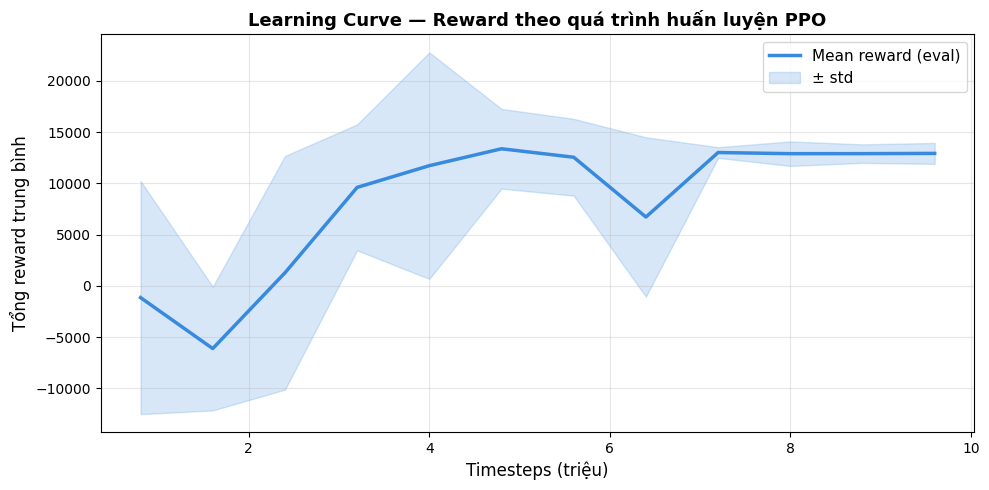


Max reward: 13378.6 tại 4.8M steps
Final reward: 12926.7 tại 9.6M steps


In [1]:
# ── Vẽ Learning Curve từ evaluations.npz (EvalCallback) ──────
import numpy as np
import matplotlib.pyplot as plt

# Load file evaluations từ EvalCallback
data = np.load("/kaggle/working/logs/evaluations.npz")
print("Keys:", list(data.keys()))
print("Timesteps:", data["timesteps"][:5], "...")
print("Results shape:", data["results"].shape)

timesteps = data["timesteps"] / 1_000_000   # đổi sang triệu
# results shape: (n_evals, n_episodes) → lấy mean
mean_reward = data["results"].mean(axis=1)
std_reward  = data["results"].std(axis=1)

# ── Vẽ reward curve ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(timesteps, mean_reward, color="#378ADD", lw=2.5, label="Mean reward (eval)")
ax.fill_between(timesteps,
                mean_reward - std_reward,
                mean_reward + std_reward,
                alpha=0.2, color="#378ADD", label="± std")

ax.set_xlabel("Timesteps (triệu)", fontsize=12)
ax.set_ylabel("Tổng reward trung bình", fontsize=12)
ax.set_title("Learning Curve — Reward theo quá trình huấn luyện PPO",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nMax reward: {mean_reward.max():.1f} tại {timesteps[mean_reward.argmax()]:.1f}M steps")
print(f"Final reward: {mean_reward[-1]:.1f} tại {timesteps[-1]:.1f}M steps")

## 6. Đánh giá kết quả
### 6.1 Bảng định lượng

In [16]:
import numpy as np
from stable_baselines3 import PPO

model = PPO.load("ppo_uav_v3")

MAP_PATHS = [
    ("/kaggle/working/maps/map_simple.json",     "Simple Map"),
    ("/kaggle/working/maps/map_mixed.json",      "Mixed Map"),
    ("/kaggle/working/maps/map_bottleneck.json", "Bottleneck Map"),
]
N_EP = 20

print(f"{'Map':<18} {'Mean':>7} {'Std':>6} {'Min':>6} {'Max':>6} {'≥90%':>6} {'Reward':>9}")
print("─" * 65)

for mp, name in MAP_PATHS:
    covs, rews = [], []
    for _ in range(N_EP):
        env = UAVPatrolEnv(map_file=mp)
        obs, _ = env.reset()
        done, total_r = False, 0.0
        while not done:
            act, _ = model.predict(obs, deterministic=True)
            obs, r, t, tr, _ = env.step(int(act))
            total_r += r; done = t or tr
        covs.append(env.coverage.sum() / env.free_cells * 100)
        rews.append(total_r)
    over90 = sum(c >= 90 for c in covs)
    flag   = " ✓" if np.mean(covs) >= 90 else " ✗"
    print(f"{name:<18} {np.mean(covs):>6.1f}%{flag}  "
          f"{np.std(covs):>5.1f}  {min(covs):>5.1f}  {max(covs):>5.1f}  "
          f"{over90:>3}/{N_EP}  {np.mean(rews):>9.0f}")

Map                   Mean    Std    Min    Max   ≥90%    Reward
─────────────────────────────────────────────────────────────────
Simple Map           94.6% ✓    7.7   63.5   97.9   17/20      11714
Mixed Map            91.5% ✓   20.9    2.2   97.8   17/20      12608
Bottleneck Map       94.0% ✓   12.6   40.7   97.8   18/20      10377


### 6.2 PPO vs Random Agent (baseline)

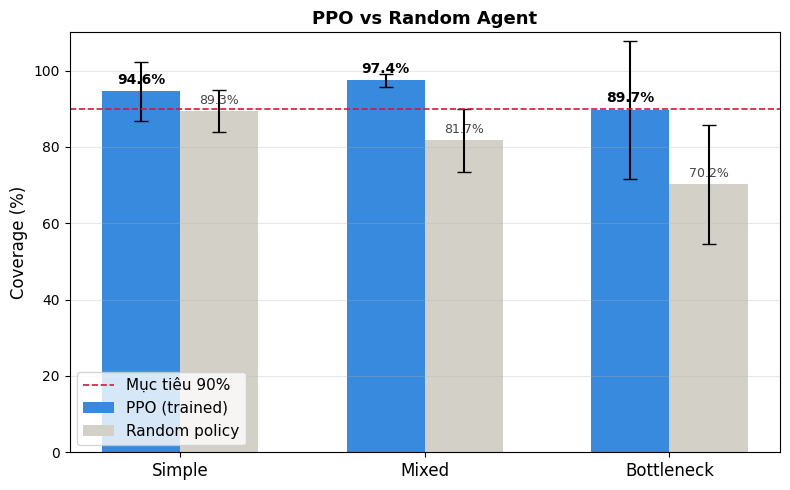


Cải thiện vs random:
  Simple: +5.3%
  Mixed: +15.7%
  Bottleneck: +19.5%


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO

model   = PPO.load("ppo_uav_v3")
MAP_PATHS = [
    ("/kaggle/working/maps/map_simple.json",     "Simple"),
    ("/kaggle/working/maps/map_mixed.json",      "Mixed"),
    ("/kaggle/working/maps/map_bottleneck.json", "Bottleneck"),
]
N_EP = 20

def run(mp, use_model):
    covs = []
    for _ in range(N_EP):
        env = UAVPatrolEnv(map_file=mp)
        obs, _ = env.reset()
        done = False
        while not done:
            act = (model.predict(obs, deterministic=True)[0]
                   if use_model else env.action_space.sample())
            obs, _, t, tr, _ = env.step(int(act))
            done = t or tr
        covs.append(env.coverage.sum() / env.free_cells * 100)
    return float(np.mean(covs)), float(np.std(covs))

names = [n for _, n in MAP_PATHS]
ppo_m, ppo_s, rnd_m, rnd_s = [], [], [], []
for mp, _ in MAP_PATHS:
    pm, ps = run(mp, True);  ppo_m.append(pm); ppo_s.append(ps)
    rm, rs = run(mp, False); rnd_m.append(rm); rnd_s.append(rs)

x, w = np.arange(len(names)), 0.32
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x-w/2, ppo_m, w, yerr=ppo_s, label="PPO (trained)",
            color="#378ADD", capsize=5)
b2 = ax.bar(x+w/2, rnd_m, w, yerr=rnd_s, label="Random policy",
            color="#D3D1C7", capsize=5)
for bar, v in zip(b1, ppo_m):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
            f"{v:.1f}%", ha="center", fontsize=10, fontweight="bold")
for bar, v in zip(b2, rnd_m):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
            f"{v:.1f}%", ha="center", fontsize=9, color="#444")
ax.axhline(90, color="crimson", ls="--", lw=1.2, label="Mục tiêu 90%")
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=12)
ax.set_ylabel("Coverage (%)", fontsize=12)
ax.set_title("PPO vs Random Agent", fontsize=13, fontweight="bold")
ax.set_ylim(0, 110); ax.legend(fontsize=11); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("ppo_vs_random.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nCải thiện vs random:")
for (_, n), pm, rm in zip(MAP_PATHS, ppo_m, rnd_m):
    print(f"  {n}: +{pm-rm:.1f}%")

### 6.3 Quỹ đạo di chuyển UAV

In [9]:
import os, zipfile
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.monitor import Monitor

# ── 1. Giải nén ──────────────────────────────────────────────────
with zipfile.ZipFile("/kaggle/working/ppo_uav_v3.zip", "r") as z:
    z.extractall("/kaggle/working/")
print("✓ Giải nén xong:", [f for f in os.listdir("/kaggle/working/") if "ppo" in f])

# ── 2. Tạo env ───────────────────────────────────────────────────
vec_env = DummyVecEnv([
    lambda: Monitor(UAVPatrolEnv(map_file="/kaggle/working/maps/map_simple.json"))
])

# ── 3. Load VecNormalize → Load model (đúng thứ tự) ─────────────
vec_env = VecNormalize.load("/kaggle/working/vec_normalize_v3.pkl", vec_env)
vec_env.training    = False
vec_env.norm_reward = False

model = PPO.load("/kaggle/working/ppo_uav_v3", env=vec_env)
print(f"✓ Load model thành công — đã train: {model.num_timesteps:,} timesteps")

# ── 4. Kiểm tra nhanh 3 map ──────────────────────────────────────
MAP_PATHS = [
    ("/kaggle/working/maps/map_simple.json",     "Simple"),
    ("/kaggle/working/maps/map_mixed.json",      "Mixed"),
    ("/kaggle/working/maps/map_bottleneck.json", "Bottleneck"),
]

print(f"\n{'Map':<12} {'Coverage':>10} {'Bước':>6}")
print("─" * 32)
for mp, name in MAP_PATHS:
    env = UAVPatrolEnv(map_file=mp)
    obs, _ = env.reset(seed=42)
    done = False
    while not done:
        act, _ = model.predict(obs, deterministic=True)
        obs, _, t, tr, _ = env.step(int(act))
        done = t or tr
    cr  = env.coverage.sum() / env.free_cells * 100
    flag = "✓" if cr >= 90 else "✗"
    print(f"{name:<12} {cr:>9.1f}%  {flag}  {env.steps:>5}")

2026-03-22 07:42:06.610984: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774165326.845210      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774165326.914152      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774165327.424712      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774165327.424752      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774165327.424755      55 computation_placer.cc:177] computation placer alr

✓ Giải nén xong: ['ppo_uav_v3.zip', 'ppo_vs_random.png']


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


✓ Load model thành công — đã train: 10,010,624 timesteps

Map            Coverage   Bước
────────────────────────────────
Simple            97.9%  ✓    157
Mixed             97.8%  ✓    176
Bottleneck        97.8%  ✓    162


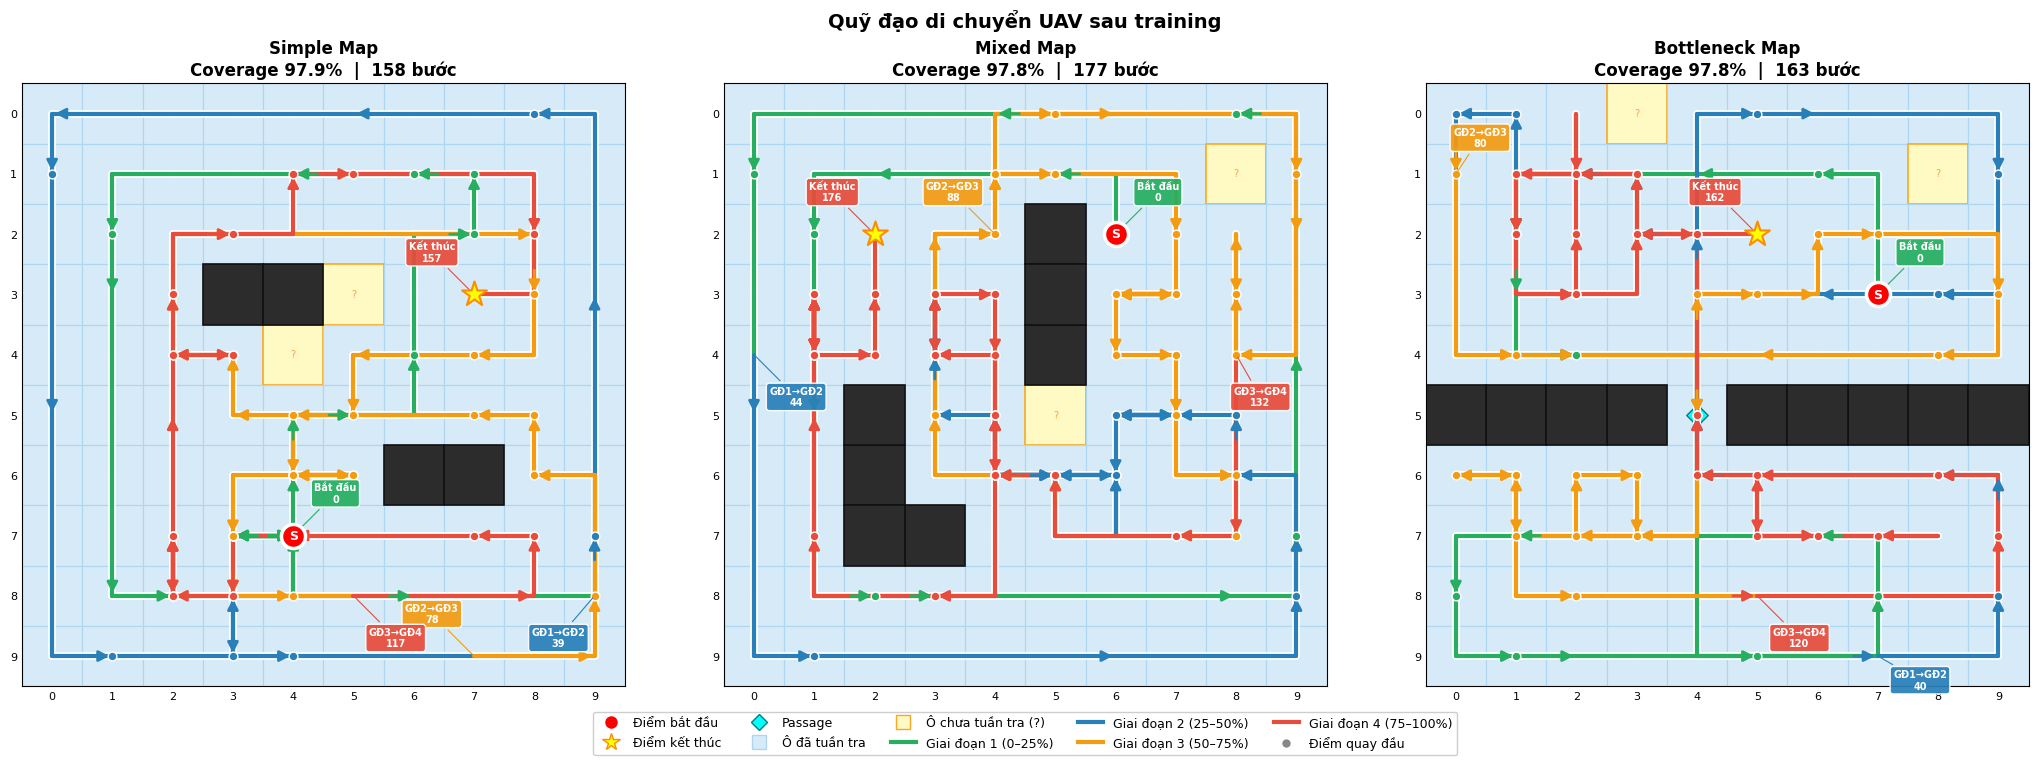

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from stable_baselines3 import PPO

model = PPO.load("ppo_uav_v3")
MAP_FILES = [
    ("/kaggle/working/maps/map_simple.json",     "Simple Map"),
    ("/kaggle/working/maps/map_mixed.json",      "Mixed Map"),
    ("/kaggle/working/maps/map_bottleneck.json", "Bottleneck Map"),
]

PHASE_COLORS = ["#27AE60", "#2980B9", "#F39C12", "#E74C3C"]

def safe_label_pos(rx, ry, ox, oy, G, obstacles):
    candidates = [
        ( ox,  oy), (-ox,  oy), ( ox, -oy), (-ox, -oy),
        ( ox,   0), (-ox,   0), (  0,  oy), (  0, -oy),
    ]
    for dx, dy in candidates:
        tx = min(max(rx + dx, 0.4), G - 1.6)
        ty = min(max(ry + dy, 0.4), G - 0.6)
        if (int(round(ty)), int(round(tx))) not in obstacles:
            return tx, ty
    return min(max(rx + ox, 0.4), G - 1.6), \
           min(max(ry + oy, 0.4), G - 0.6)

fig, axes = plt.subplots(1, 3, figsize=(21, 7), constrained_layout=True)

for ax, (mp, title) in zip(axes, MAP_FILES):
    env = UAVPatrolEnv(map_file=mp)
    obs, _ = env.reset(seed=42)
    traj, done = [env.uav_pos.copy()], False
    while not done:
        act, _ = model.predict(obs, deterministic=True)
        obs, _, t, tr, _ = env.step(int(act))
        traj.append(env.uav_pos.copy())
        done = t or tr
    traj = np.array(traj)
    n    = len(traj)
    cr   = env.coverage.sum() / env.free_cells * 100
    G    = env.grid_size
    phase_size = n // 4

    # ── [SỬA] Nền: phân biệt ô đã thăm / chưa thăm ──────────────
    ax.set_facecolor("#FFFFFF")
    unvisited_count = 0
    for r in range(G):
        for c in range(G):
            if (r, c) not in env.obstacles:
                visited = env.coverage[r, c] > 0
                if visited:
                    # Ô đã thăm — xanh nhạt
                    ax.add_patch(Rectangle(
                        (c - 0.5, r - 0.5), 1, 1,
                        facecolor="#D6EAF8", edgecolor="#AED6F1",
                        linewidth=0.8, zorder=1))
                else:
                    # Ô CHƯA thăm — vàng nổi bật
                    unvisited_count += 1
                    ax.add_patch(Rectangle(
                        (c - 0.5, r - 0.5), 1, 1,
                        facecolor="#FFF9C4", edgecolor="#F9A825",
                        linewidth=1.2, zorder=1))
                    ax.text(c, r, "?",
                            ha="center", va="center",
                            fontsize=7, color="#F57F17",
                            alpha=0.7, zorder=2)

    # ── Obstacles ────────────────────────────────────────────────
    for (ox, oy) in env.obstacles:
        ax.add_patch(Rectangle(
            (oy - 0.5, ox - 0.5), 1, 1,
            facecolor="#2C2C2C", edgecolor="#111111",
            linewidth=1.2, zorder=2))

    # ── Passages ─────────────────────────────────────────────────
    for (px, py) in env.passages:
        ax.scatter(py, px, s=120, c="cyan", marker="D",
                   edgecolors="teal", linewidths=1, zorder=3)

    # ── Viền trắng ───────────────────────────────────────────────
    for i in range(n - 1):
        ax.plot(traj[i:i+2, 1], traj[i:i+2, 0],
                color="white", linewidth=5.5,
                solid_capstyle="round", zorder=4)

    # ── Đường màu theo giai đoạn ─────────────────────────────────
    for i in range(n - 1):
        phase = min(i // phase_size, 3)
        ax.plot(traj[i:i+2, 1], traj[i:i+2, 0],
                color=PHASE_COLORS[phase], linewidth=3.0,
                solid_capstyle="round", zorder=5)

    # ── Mũi tên + điểm quay đầu ──────────────────────────────────
    prev_dir = None
    for i in range(1, n - 1):
        dy = traj[i, 0] - traj[i-1, 0]
        dx = traj[i, 1] - traj[i-1, 1]
        if dx == 0 and dy == 0:
            continue
        curr_dir = (dy, dx)
        phase    = min(i // phase_size, 3)
        color    = PHASE_COLORS[phase]
        is_turn     = (prev_dir is not None and curr_dir != prev_dir)
        is_interval = (i % 5 == 0)
        if is_turn or is_interval:
            ax.annotate("",
                xy     = (traj[i, 1], traj[i, 0]),
                xytext = (traj[i, 1] - dx * 0.45,
                          traj[i, 0] - dy * 0.45),
                arrowprops=dict(arrowstyle="-|>",
                                color=color, lw=2.0,
                                mutation_scale=16),
                zorder=6)
            if is_turn:
                ax.scatter(traj[i, 1], traj[i, 0],
                           s=40, c=color,
                           edgecolors="white", linewidths=1,
                           zorder=7)
        prev_dir = curr_dir

    # ── Nhãn số bước tại 5 mốc giai đoạn ────────────────────────
    phase_boundaries = [
        (0,              "Bắt đầu\n0"),
        (phase_size,     f"GĐ1→GĐ2\n{phase_size}"),
        (phase_size * 2, f"GĐ2→GĐ3\n{phase_size * 2}"),
        (phase_size * 3, f"GĐ3→GĐ4\n{phase_size * 3}"),
        (n - 1,          f"Kết thúc\n{n - 1}"),
    ]
    raw_offsets = [
        ( 0.7, -0.7),
        ( 0.7,  0.7),
        (-0.7, -0.7),
        ( 0.7,  0.7),
        (-0.7, -0.7),
    ]
    for k, (idx, lbl) in enumerate(phase_boundaries):
        rx     = traj[idx, 1]
        ry     = traj[idx, 0]
        ox, oy = raw_offsets[k]
        tx, ty = safe_label_pos(rx, ry, ox, oy, G, env.obstacles)
        phase_k = min(idx // max(phase_size, 1), 3)
        fc      = PHASE_COLORS[phase_k]
        ax.annotate(lbl,
            xy       = (rx, ry),
            xytext   = (tx, ty),
            fontsize   = 7,
            fontweight = "bold",
            color      = "white",
            ha         = "center",
            va         = "center",
            bbox=dict(boxstyle="round,pad=0.3",
                      fc=fc, ec="white",
                      lw=1.0, alpha=0.93),
            arrowprops=dict(arrowstyle="-",
                            color=fc, lw=0.8),
            zorder=10)

    # ── START / END ───────────────────────────────────────────────
    ax.scatter(traj[0, 1], traj[0, 0], s=300, c="red",
               edgecolors="white", linewidths=2.5, zorder=11)
    ax.text(traj[0, 1], traj[0, 0], "S",
            ha="center", va="center",
            fontsize=9, fontweight="bold",
            color="white", zorder=12)

    ax.scatter(traj[-1, 1], traj[-1, 0], s=350,
               c="yellow", marker="*",
               edgecolors="darkorange", linewidths=1.5, zorder=11)

   # ── Axes ─────────────────────────────────────────────────────
    tc = "#27AE60" if cr >= 90 else "#E74C3C"
    ax.set_title(f"{title}\nCoverage {cr:.1f}%  |  {n} bước",
                 fontsize=12, fontweight="bold", color="black")
    ax.set_xlim(-0.5, G - 0.5)
    ax.set_ylim(G - 0.5, -0.5)
    ax.set_xticks(range(G))
    ax.set_yticks(range(G))
    ax.tick_params(labelsize=8, length=0)
    ax.set_aspect("equal")

# ── Legend ────────────────────────────────────────────────────────
handles = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor="red",
           markersize=10, label="Điểm bắt đầu"),
    Line2D([0],[0], marker="*", color="w", markerfacecolor="yellow",
           markersize=13, markeredgecolor="darkorange",
           label="Điểm kết thúc"),
    Line2D([0],[0], marker="D", color="w", markerfacecolor="cyan",
           markersize=8, markeredgecolor="teal", label="Passage"),
    Line2D([0],[0], marker="s", color="w", markerfacecolor="#D6EAF8",
           markeredgecolor="#AED6F1", markersize=10,
           label="Ô đã tuần tra"),
    Line2D([0],[0], marker="s", color="w", markerfacecolor="#FFF9C4",
           markeredgecolor="#F9A825", markersize=10,
           label="Ô chưa tuần tra (?)"),
    Line2D([0],[0], color=PHASE_COLORS[0], lw=3,
           label="Giai đoạn 1 (0–25%)"),
    Line2D([0],[0], color=PHASE_COLORS[1], lw=3,
           label="Giai đoạn 2 (25–50%)"),
    Line2D([0],[0], color=PHASE_COLORS[2], lw=3,
           label="Giai đoạn 3 (50–75%)"),
    Line2D([0],[0], color=PHASE_COLORS[3], lw=3,
           label="Giai đoạn 4 (75–100%)"),
    Line2D([0],[0], marker="o", color="w",
           markerfacecolor="#888888", markersize=7,
           label="Điểm quay đầu"),
]
fig.legend(handles=handles,
           loc="lower center", ncol=5,
           fontsize=9, framealpha=0.95,
           bbox_to_anchor=(0.5, -0.08))

plt.suptitle("Quỹ đạo di chuyển UAV sau training",
             fontsize=14, fontweight="bold")
plt.savefig("trajectory.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()

### 6.4 Visit Count Heatmap

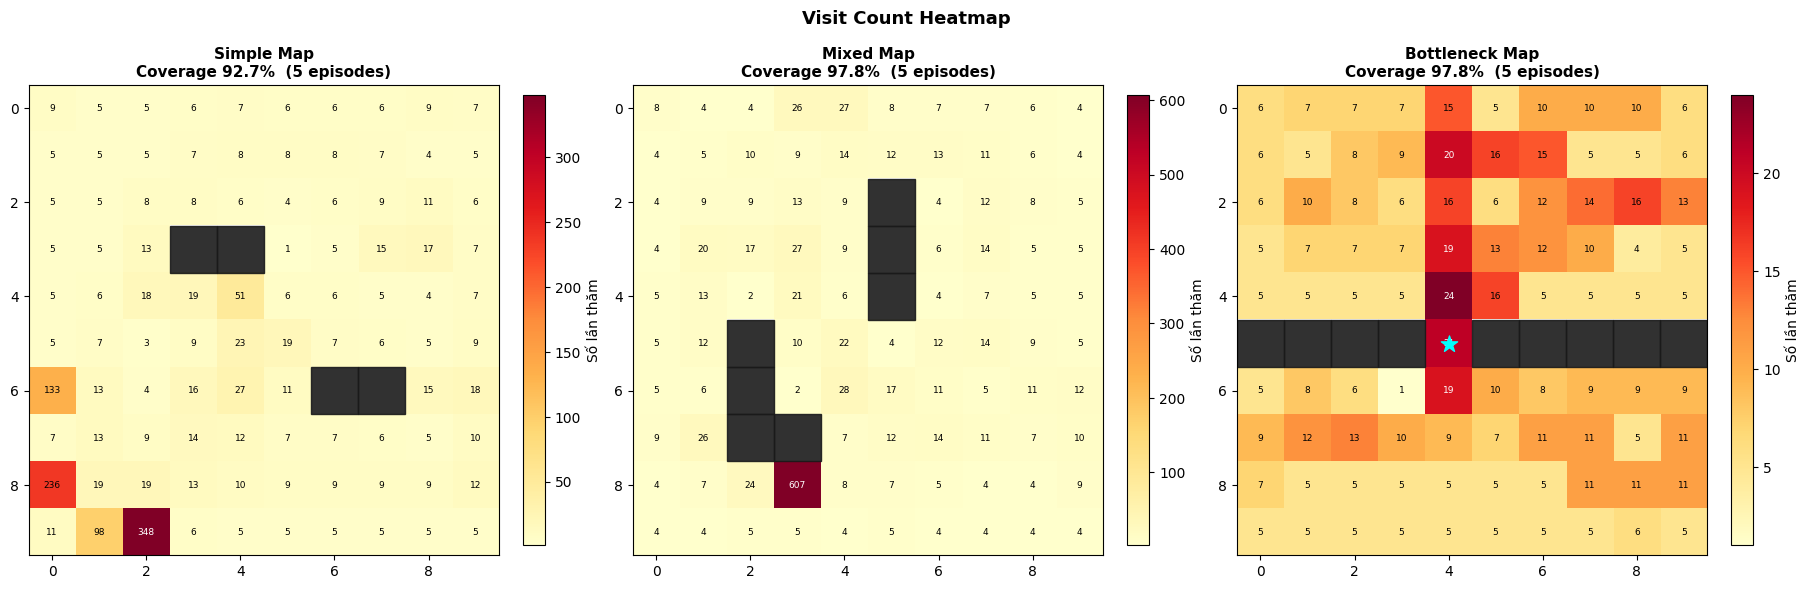

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from stable_baselines3 import PPO

model = PPO.load("ppo_uav_v3")
MAP_FILES = [
    ("/kaggle/working/maps/map_simple.json",     "Simple Map"),
    ("/kaggle/working/maps/map_mixed.json",      "Mixed Map"),
    ("/kaggle/working/maps/map_bottleneck.json", "Bottleneck Map"),
]
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
for ax, (mp, title) in zip(axes, MAP_FILES):
    total_visits = None
    for _ in range(5):
        env = UAVPatrolEnv(map_file=mp)
        obs, _ = env.reset()
        done = False
        while not done:
            act, _ = model.predict(obs, deterministic=True)
            obs, _, t, tr, _ = env.step(int(act))
            done = t or tr
        total_visits = env.visit_count.copy() if total_visits is None                        else total_visits + env.visit_count

    masked = np.ma.masked_where(
        np.array([[1 if (r,c) in env.obstacles else 0
                   for c in range(env.grid_size)]
                  for r in range(env.grid_size)]) == 1, total_visits)
    im = ax.imshow(masked, cmap="YlOrRd", origin="upper")
    for (ox,oy) in env.obstacles:
        ax.add_patch(Rectangle((oy-.5,ox-.5),1,1,color="#1a1a1a",alpha=0.9))
    for (px,py) in env.passages:
        ax.scatter(py, px, s=150, c="cyan", marker="*", zorder=5)
    for r in range(env.grid_size):
        for c in range(env.grid_size):
            if (r,c) not in env.obstacles and total_visits[r,c] > 0:
                ax.text(c, r, int(total_visits[r,c]),
                        ha="center", va="center", fontsize=6.5,
                        color="black" if total_visits[r,c] < total_visits.max()*0.7 else "white")
    cr = (env.coverage > 0).sum() / env.free_cells * 100
    ax.set_title(f"{title}\nCoverage {cr:.1f}%  (5 episodes)",
                 fontsize=11, fontweight="bold")
    fig.colorbar(im, ax=ax, shrink=0.8, label="Số lần thăm")

plt.suptitle("Visit Count Heatmap", fontsize=13, fontweight="bold")
plt.savefig("visit_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.5 Coverage tích lũy theo từng bước

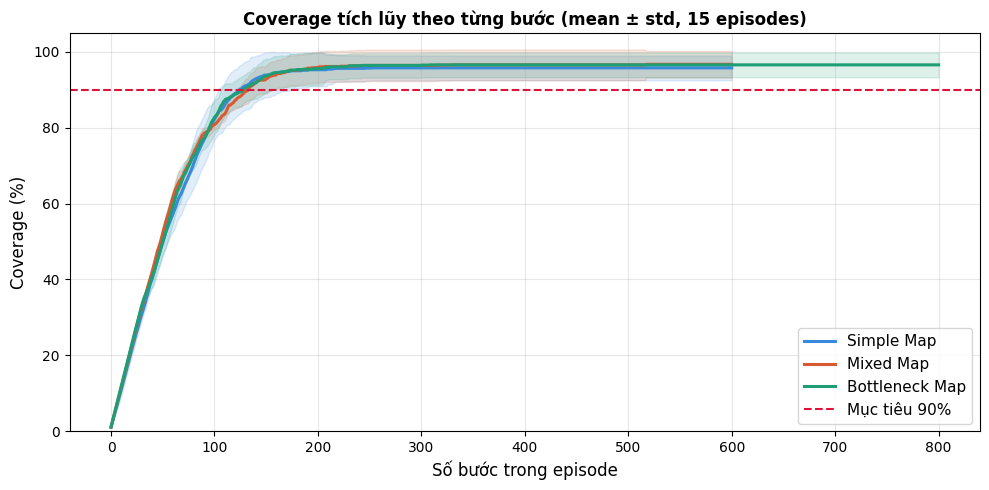

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO

model = PPO.load("ppo_uav_v3")
MAP_FILES = [
    ("/kaggle/working/maps/map_simple.json",     "Simple Map",     "#378ADD"),
    ("/kaggle/working/maps/map_mixed.json",      "Mixed Map",      "#D85A30"),
    ("/kaggle/working/maps/map_bottleneck.json", "Bottleneck Map", "#1D9E75"),
]
fig, ax = plt.subplots(figsize=(10, 5))
for mp, title, color in MAP_FILES:
    all_curves = []
    for _ in range(15):
        env = UAVPatrolEnv(map_file=mp)
        obs, _ = env.reset()
        done = False
        curve = [env.coverage.sum()/env.free_cells*100]
        while not done:
            act, _ = model.predict(obs, deterministic=True)
            obs, _, t, tr, _ = env.step(int(act))
            curve.append(env.coverage.sum()/env.free_cells*100)
            done = t or tr
        all_curves.append(curve)
    max_len = max(len(c) for c in all_curves)
    padded  = np.array([c+[c[-1]]*(max_len-len(c)) for c in all_curves])
    mean, std = padded.mean(0), padded.std(0)
    steps = np.arange(max_len)
    ax.plot(steps, mean, label=title, color=color, lw=2.2)
    ax.fill_between(steps, mean-std, mean+std, alpha=0.15, color=color)

ax.axhline(90, color="crimson", ls="--", lw=1.5, label="Mục tiêu 90%")
ax.set_xlabel("Số bước trong episode", fontsize=12)
ax.set_ylabel("Coverage (%)", fontsize=12)
ax.set_title("Coverage tích lũy theo từng bước (mean ± std, 15 episodes)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=11); ax.grid(alpha=0.3); ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig("coverage_progress.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.6 Số bước để đạt 90% coverage

In [21]:
import numpy as np
from stable_baselines3 import PPO

model = PPO.load("ppo_uav_v3")
MAP_FILES = [
    ("/kaggle/working/maps/map_simple.json",     "Simple Map"),
    ("/kaggle/working/maps/map_mixed.json",      "Mixed Map"),
    ("/kaggle/working/maps/map_bottleneck.json", "Bottleneck Map"),
]
N_EP, TARGET = 20, 90.0

print(f"{'Map':<18} {'Thành công':>12} {'Bước TB':>10} {'Hiệu suất':>12}")
print("─" * 58)
for mp, name in MAP_FILES:
    success, steps_list, eff_list = 0, [], []
    for _ in range(N_EP):
        env = UAVPatrolEnv(map_file=mp)
        obs, _ = env.reset()
        done, reached, step_hit = False, False, None
        while not done:
            act, _ = model.predict(obs, deterministic=True)
            obs, _, t, tr, _ = env.step(int(act))
            done = t or tr
            if env.coverage.sum()/env.free_cells*100 >= TARGET and not reached:
                step_hit = env.steps; reached = True
        if reached: success += 1; steps_list.append(step_hit)
        eff_list.append(env.coverage.sum()/env.free_cells*100/env.steps*100)
    avg_steps = np.mean(steps_list) if steps_list else float("nan")
    print(f"{name:<18} {success:>5}/{N_EP}  "
          f"{avg_steps:>9.0f}   {np.mean(eff_list):>9.2f}%/step")

Map                  Thành công    Bước TB    Hiệu suất
──────────────────────────────────────────────────────────
Simple Map            17/20        116       50.08%/step
Mixed Map             17/20        129       44.84%/step
Bottleneck Map        18/20        117       43.06%/step


## 7. Sensitivity Analysis — Tối ưu siêu tham số

SENSITIVITY ANALYSIS  (11 runs × 1 seed × 800,000 steps)
Ước tính: ~79 phút
[ 1/11] Baseline ★                  ETA   0min  simple= 35.5%  mixed= 37.1%  bottleneck= 36.4%  mean= 36.3%  ◄ BASELINE
[ 2/11] lr = 1e-4  ↓                ETA  64min  simple= 23.2%  mixed= 25.3%  bottleneck= 27.3%  mean= 25.3%  (-11.0%)
[ 3/11] lr = 3e-4  ↑                ETA  58min  simple= 39.8%  mixed= 36.3%  bottleneck= 23.2%  mean= 33.1%  (-3.2%)
[ 4/11] ent = 0.02  ↓               ETA  51min  simple= 33.7%  mixed= 39.0%  bottleneck= 27.9%  mean= 33.5%  (-2.8%)
[ 5/11] ent = 0.06  ↑               ETA  45min  simple= 30.3%  mixed= 24.6%  bottleneck= 27.1%  mean= 27.3%  (-9.0%)
[ 6/11] γ = 0.990  ↓                ETA  38min  simple= 49.9%  mixed= 31.9%  bottleneck= 31.0%  mean= 37.6%  (+1.3%)
[ 7/11] γ = 0.999  ↑                ETA  32min  simple= 29.2%  mixed= 33.7%  bottleneck= 16.3%  mean= 26.4%  (-9.9%)
[ 8/11] n_steps = 1024  ↓           ETA  26min  simple= 41.3%  mixed= 48.5%  bottleneck= 27.5%  mean=

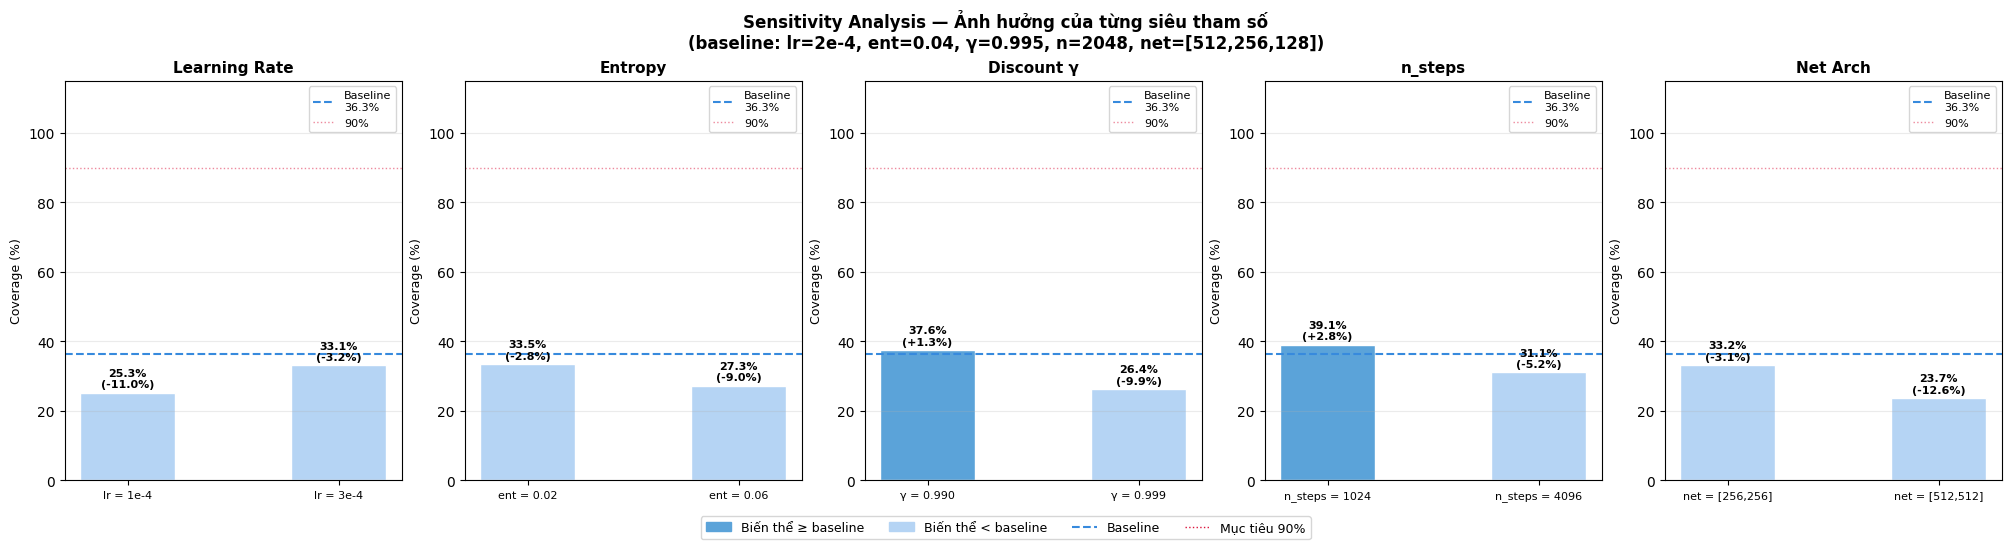


Baseline mean: 36.3%
→ Biến thể tốt nhất: n_steps = 1024  ↓ (mean=39.1%)
Tổng thời gian: 70 phút


<Figure size 640x480 with 0 Axes>

In [23]:
import numpy as np, time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.monitor import Monitor

if "UAVPatrolEnv" not in dir():
    raise RuntimeError("Chạy Runtime → Run all trước")

BASELINE = dict(learning_rate=2e-4, gamma=0.995, n_steps=2048,
                ent_coef=0.04, net_arch=[512,256,128],
                batch_size=256, clip_range=0.2, n_epochs=10,
                gae_lambda=0.95, device="cuda")

VARIANTS = [
    ("Baseline ★",          "learning_rate", 2e-4,          "lr"),
    ("lr = 1e-4  ↓",        "learning_rate", 1e-4,          "lr"),
    ("lr = 3e-4  ↑",        "learning_rate", 3e-4,          "lr"),
    ("ent = 0.02  ↓",       "ent_coef",      0.02,          "ent"),
    ("ent = 0.06  ↑",       "ent_coef",      0.06,          "ent"),
    ("γ = 0.990  ↓",        "gamma",         0.990,         "gamma"),
    ("γ = 0.999  ↑",        "gamma",         0.999,         "gamma"),
    ("n_steps = 1024  ↓",   "n_steps",       1024,          "nsteps"),
    ("n_steps = 4096  ↑",   "n_steps",       4096,          "nsteps"),
    ("net = [256,256]  ↓",  "net_arch",      [256,256],     "net"),
    ("net = [512,512]  ↑",  "net_arch",      [512,512],     "net"),
]

TRAIN_STEPS   = 800_000
EVAL_EPISODES = 8
SEED          = 42
EVAL_MAPS     = [("/kaggle/working/maps/map_simple.json",     "simple"),
                 ("/kaggle/working/maps/map_mixed.json",      "mixed"),
                 ("/kaggle/working/maps/map_bottleneck.json", "bottleneck")]

def build_vec(gamma):
    return VecNormalize(DummyVecEnv([
        lambda: Monitor(UAVPatrolEnv(map_file="/kaggle/working/maps/map_simple.json")),
        lambda: Monitor(UAVPatrolEnv(map_file="/kaggle/working/maps/map_simple.json")),
        lambda: Monitor(UAVPatrolEnv(map_file="/kaggle/working/maps/map_mixed.json")),
        lambda: Monitor(UAVPatrolEnv(map_file="/kaggle/working/maps/map_mixed.json")),
        lambda: Monitor(UAVPatrolEnv(map_file="/kaggle/working/maps/map_mixed.json")),
        lambda: Monitor(UAVPatrolEnv(map_file="/kaggle/working/maps/map_bottleneck.json")),
        lambda: Monitor(UAVPatrolEnv(map_file="/kaggle/working/maps/map_bottleneck.json")),
        lambda: Monitor(UAVPatrolEnv(map_file="/kaggle/working/maps/map_bottleneck.json")),
    ]), norm_obs=False, norm_reward=True, clip_reward=10, gamma=gamma)

def eval_cov(model):
    out = {}
    for mp, name in EVAL_MAPS:
        covs = [0.0]*EVAL_EPISODES
        for i in range(EVAL_EPISODES):
            env = UAVPatrolEnv(map_file=mp)
            obs, _ = env.reset()
            done = False
            while not done:
                act, _ = model.predict(obs, deterministic=True)
                obs, _, t, tr, _ = env.step(int(act)); done = t or tr
            covs[i] = env.coverage.sum()/env.free_cells*100
        out[name] = round(float(np.mean(covs)), 1)
    out["mean"] = round(float(np.mean(list(out.values()))), 1)
    return out

records = []
t0 = time.time()
n  = len(VARIANTS)
print(f"SENSITIVITY ANALYSIS  ({n} runs × 1 seed × {TRAIN_STEPS:,} steps)")
print(f"Ước tính: ~{n*TRAIN_STEPS/1e6*9:.0f} phút")
print("=" * 60)

for i, (label, pkey, pval, grp) in enumerate(VARIANTS):
    eta = (time.time()-t0)/max(i,1)*(n-i)
    is_bl = (label == "Baseline ★")
    print(f"[{i+1:2d}/{n}] {label:<26}  ETA {eta/60:>3.0f}min", end="  ", flush=True)
    params = dict(BASELINE); params[pkey] = pval
    vec = build_vec(params["gamma"])
    mdl = PPO("MlpPolicy", vec, verbose=0, seed=SEED,
              learning_rate=params["learning_rate"], gamma=params["gamma"],
              n_steps=params["n_steps"], batch_size=params["batch_size"],
              ent_coef=params["ent_coef"], clip_range=params["clip_range"],
              n_epochs=params["n_epochs"], gae_lambda=params["gae_lambda"],
              policy_kwargs=dict(net_arch=list(params["net_arch"])),
              device=params["device"])
    try:
        mdl.learn(total_timesteps=TRAIN_STEPS, progress_bar=False)
        res = eval_cov(mdl)
    except Exception as e:
        print(f"ERROR: {e}"); vec.close(); continue
    vec.close()
    bl = next((r["mean"] for r in records if r["is_baseline"]), None)
    diff = f"  ({res['mean']-bl:+.1f}%)" if bl and not is_bl else ""
    print(f"simple={res['simple']:>5.1f}%  mixed={res['mixed']:>5.1f}%  "
          f"bottleneck={res['bottleneck']:>5.1f}%  mean={res['mean']:>5.1f}%{diff}"
          + ("  ◄ BASELINE" if is_bl else ""))
    records.append(dict(label=label, group=grp, is_baseline=is_bl, **res))


# ── Biểu đồ ──────────────────────────────────────────────────────
bl_mean = next(r["mean"] for r in records if r["is_baseline"])
groups  = [("lr","Learning Rate"),("ent","Entropy"),
           ("gamma","Discount γ"),("nsteps","n_steps"),("net","Net Arch")]

fig, axes = plt.subplots(1,5,figsize=(20,5),constrained_layout=True)

for ax, (gid, gname) in zip(axes, groups):
    # Lấy đúng variants của group, LOẠI BỎ baseline
    group_rows = [r for r in records
                  if r["group"] == gid and not r["is_baseline"]]

    if not group_rows:
        ax.set_title(gname); continue

    xlabs = [r["label"].split("  ")[0] for r in group_rows]
    means = [r["mean"] for r in group_rows]
    cols  = ["#5BA3D9" if r["mean"] >= bl_mean else "#B5D4F4"
             for r in group_rows]

    bars = ax.bar(xlabs, means, color=cols, width=0.45, edgecolor="white")

    for bar, v in zip(bars, means):
        diff = v - bl_mean
        sign = "+" if diff >= 0 else ""
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.8,
                f"{v:.1f}%\n({sign}{diff:.1f}%)",
                ha="center", va="bottom", fontsize=8, fontweight="bold")

    ax.axhline(bl_mean, color="#378ADD", ls="--", lw=1.5,
               label=f"Baseline\n{bl_mean:.1f}%")
    ax.axhline(90, color="crimson", ls=":", lw=1,
               alpha=0.5, label="90%")
    ax.set_title(gname, fontsize=11, fontweight="bold")
    ax.set_ylabel("Coverage (%)", fontsize=9)
    ax.set_ylim(0, 115)
    ax.tick_params(axis="x", labelsize=8)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(fontsize=8, loc="upper right")

fig.legend(handles=[
    mpatches.Patch(color="#5BA3D9", label="Biến thể ≥ baseline"),
    mpatches.Patch(color="#B5D4F4", label="Biến thể < baseline"),
    plt.Line2D([0],[0], color="#378ADD", ls="--", lw=1.5, label="Baseline"),
    plt.Line2D([0],[0], color="crimson", ls=":", lw=1, label="Mục tiêu 90%"),
], loc="lower center", ncol=4, fontsize=9, bbox_to_anchor=(0.5,-0.08))

plt.suptitle(
    "Sensitivity Analysis — Ảnh hưởng của từng siêu tham số\n"
    f"(baseline: lr=2e-4, ent=0.04, γ=0.995, n=2048, net=[512,256,128])",
    fontsize=12, fontweight="bold")
plt.savefig("sensitivity_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Kết luận ─────────────────────────────────────────────────────
print(f"\nBaseline mean: {bl_mean:.1f}%")
better = [r for r in records if not r["is_baseline"] and r["mean"] > bl_mean+1.5]
if not better:
    print("→ Baseline đã là tối ưu cục bộ. Không biến thể nào cải thiện đáng kể.")
else:
    best_var = max(better, key=lambda r: r["mean"])
    print(f"→ Biến thể tốt nhất: {best_var['label']} (mean={best_var['mean']:.1f}%)")
print(f"Tổng thời gian: {(time.time()-t0)/60:.0f} phút")
plt.savefig("sensitivity_analysis.png", dpi=150, bbox_inches="tight")